In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
df_grids =pd.read_csv('../grid_data/grids.csv',index_col=0)

In [3]:
df_2019 =pd.read_csv('../new_model/2019_pred.csv',index_col=0)

In [4]:
cmaq_2019 = df_2019.groupby('index')['cmaq_MDA8'].mean().reset_index()
cmaq_2019 =pd.merge(cmaq_2019,df_grids,on='index')

In [5]:
obs_2019 = df_2019.groupby('index')['MDA8'].mean().reset_index()
obs_2019 =pd.merge(obs_2019,df_grids,on='index')

In [6]:
annual_2019 = df_2019.groupby('index')['prediction_1'].mean().reset_index()
annual_2019 =pd.merge(annual_2019,df_grids,on='index')
annual_2019.set_index(['lat', 'lon'], inplace=True)
xr_2019 = annual_2019.to_xarray()

In [7]:
cmaq_2019.set_index(['lat', 'lon'], inplace=True)
xr_cmaq = cmaq_2019.to_xarray()
obs_2019.set_index(['lat', 'lon'], inplace=True)
xr_obs = obs_2019.to_xarray()

In [8]:
ml_2019=xr_2019.rename({'prediction_1': '2019'})
xr_merged =ml_2019.merge(xr_cmaq)
xr_merged =xr_merged.merge(xr_obs)

In [9]:
mean_2019 = xr_merged['2019'].mean(skipna=True)
mean_cmaq_MDA8 = xr_merged['cmaq_MDA8'].mean(skipna=True)
mean_obs_2019 =xr_merged['MDA8'].mean(skipna=True)

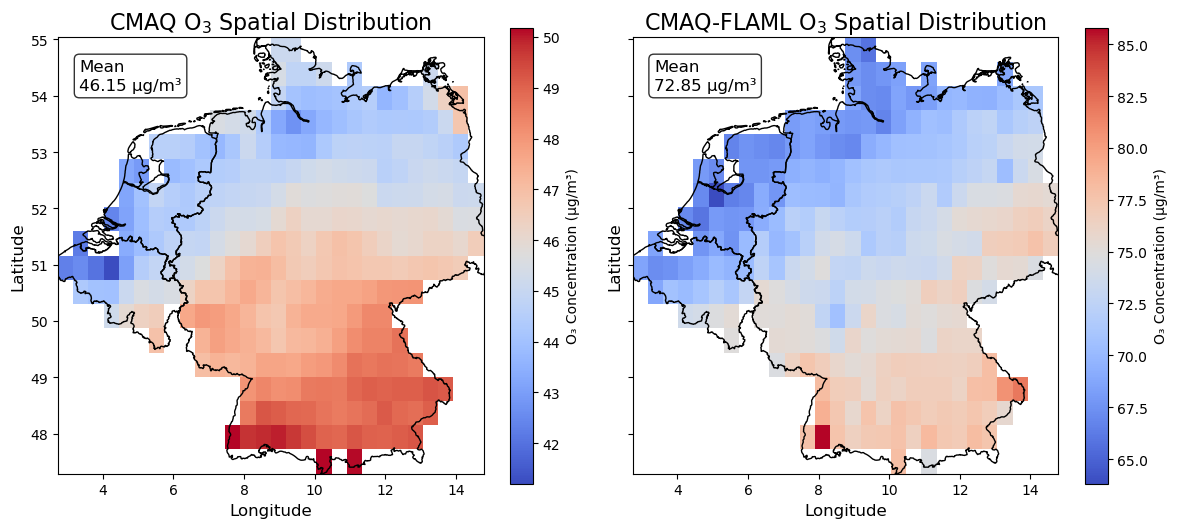

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import geopandas as gpd
shapefile = gpd.read_file('../map/germany.shp')
ds_cmaq_MDA8 = xr_merged['cmaq_MDA8']
ds_2019 = xr_merged['2019']
vmin_cmaq_MDA8 = np.nanmin(ds_cmaq_MDA8.values)
vmax_cmaq_MDA8 = np.nanmax(ds_cmaq_MDA8.values)
vmin_2018 = np.nanmin(ds_2019.values)
vmax_2018 = np.nanmax(ds_2019.values)
cmap = 'coolwarm'
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
im1 = ds_cmaq_MDA8.plot(ax=axs[0], cmap=cmap, add_colorbar=True, 
                        vmin=vmin_cmaq_MDA8, vmax=vmax_cmaq_MDA8,
                        cbar_kwargs={'shrink': 0.8})  
axs[0].set_title('CMAQ O$_3$ Spatial Distribution',fontsize=16)
shapefile.plot(ax=axs[0], edgecolor='black', facecolor='none')
cbar1 = im1.colorbar
cbar1.set_label('O₃ Concentration (μg/m³)')
axs[0].text(0.05, 0.95, f'Mean\n{mean_cmaq_MDA8:.2f} μg/m³', 
            transform=axs[0].transAxes,
            verticalalignment='top',
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))
axs[0].set_xlabel('Longitude', fontsize=12)
axs[0].set_ylabel('Latitude', fontsize=12)
im2 = ds_2019.plot(ax=axs[1], cmap=cmap, add_colorbar=True, 
                   vmin=vmin_2018, vmax=vmax_2018,
                   cbar_kwargs={'shrink': 0.8}) 
axs[1].set_title('CMAQ-FLAML O$_3$ Spatial Distribution',fontsize=16)
shapefile.plot(ax=axs[1], edgecolor='black', facecolor='none')
cbar2 = im2.colorbar
cbar2.set_label('O₃ Concentration (μg/m³)')
axs[1].text(0.05, 0.95, f'Mean\n{mean_2019:.2f} μg/m³', 
            transform=axs[1].transAxes,
            verticalalignment='top',
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))
axs[1].set_xlabel('Longitude', fontsize=12)
axs[1].set_ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.show()


In [11]:
df=pd.read_csv('../new_model/resid2019_sites.csv',index_col=0)

In [12]:
mean1 =np.mean(df['resid1'])
mean2 =np.mean(df['resid2'])
print(mean1,mean2)

-23.53668316481813 1.5890698367560079


/tmp/ipykernel_4000179/2290429336.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.96, 1])


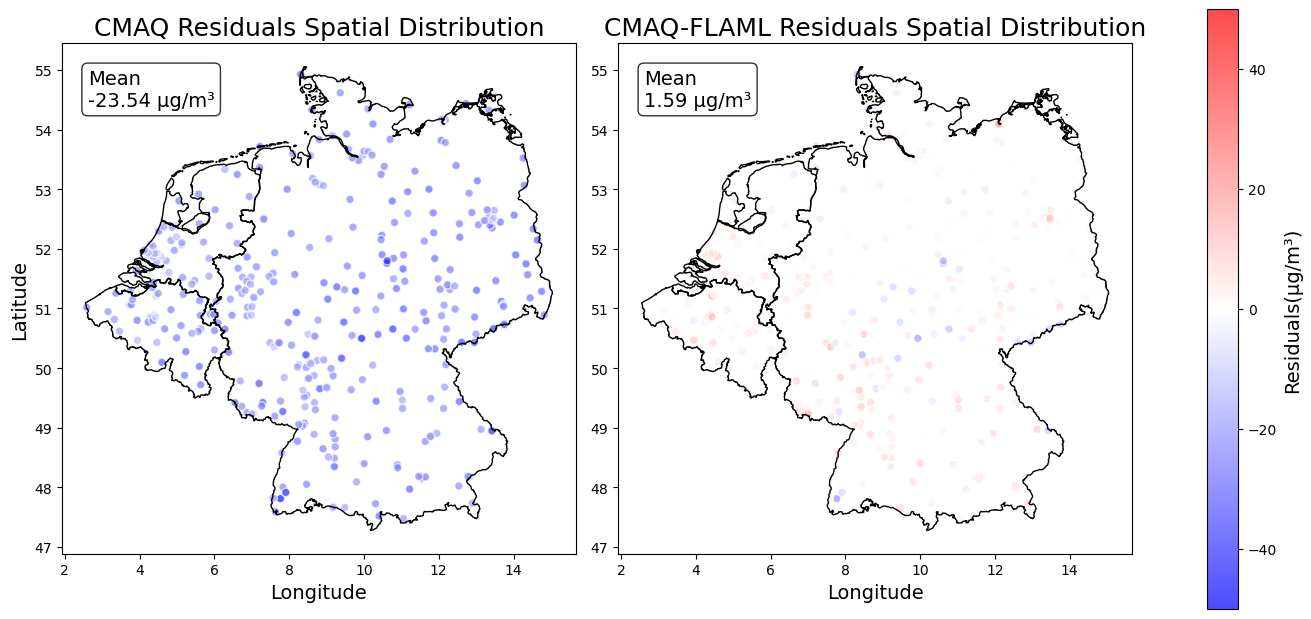

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
min_val = -50
max_val = 50
norm = TwoSlopeNorm(vmin=min_val, vcenter=0, vmax=max_val)
sc1 = ax1.scatter(
    x=df['2'],       
    y=df['1'],       
    c=df['resid1'],  
    cmap='bwr',      
    alpha=0.7,
    edgecolor='w',
    norm=norm
)
ax1.set_title('CMAQ Residuals Spatial Distribution',fontsize=18)
ax1.set_xlabel('Longitude',fontsize=14)
ax1.set_ylabel('Latitude',fontsize=14)
shapefile.plot(ax=ax1, edgecolor='black', facecolor='none')
ax1.text(0.05, 0.95, f'Mean\n{mean1:.2f} μg/m³', 
         transform=ax1.transAxes,
         verticalalignment='top',
         fontsize=14,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))
sc2 = ax2.scatter(
    x=df['2'],       
    y=df['1'],       
    c=df['resid2'],  
    cmap='bwr',      
    alpha=0.7,
    edgecolor='w',
    norm=norm
)
ax2.set_title('CMAQ-FLAML Residuals Spatial Distribution',fontsize=18)
ax2.set_xlabel('Longitude',fontsize=14)
ax2.text(0.05, 0.95, f'Mean\n{mean2:.2f} μg/m³', 
         transform=ax2.transAxes,
         verticalalignment='top',
         fontsize=14,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))
shapefile.plot(ax=ax2, edgecolor='black', facecolor='none')
cax = fig.add_axes([1.01, 0.00, 0.026, 1.0])  
cbar = fig.colorbar(sc1, cax=cax)
cbar.set_label('Residuals(μg/m³)', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.96, 1])
plt.show()


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

In [ ]:
df1 = pd.read_csv('../grid_data/grids.csv',index_col=0)
df2 = pd.read_csv('../data_process/MDA8_2019.csv',index_col=0)
df3 = pd.read_csv('../data_fusion/sites.csv',index_col=0)
#ppb transfer to μg/m3
df2['cmaq_8_max']=df2['cmaq_8_max']*0.467

In [16]:
df23 =pd.merge(df2,df3,left_on='sites',right_on='0',how='left')

In [ ]:
df23_lat_lon = df23[['1', '2']].values  
df1_lat_lon = df1[['lat', 'lon']].values  

distance_matrix = cdist(df23_lat_lon, df1_lat_lon, metric='euclidean')

nearest_indices = np.argmin(distance_matrix, axis=1)

df23['nearest_index'] = nearest_indices

print(df23)

              time    sites  obs_8_max  cmaq_8_max        0          1  \
0       2019-01-04  betb004  23.785714   24.088142  betb004  50.852051   
1       2019-01-04  betb011  38.357143   21.274522  betb011  50.857806   
2       2019-01-04  betm705  44.625000   28.532625  betm705  50.945359   
3       2019-01-04  betmeu1  30.562500   20.593653  betmeu1  50.895001   
4       2019-01-04  betn012  57.000000   28.529405  betn012  51.254574   
...            ...      ...        ...         ...      ...        ...   
123944  2019-12-30  nl00818  23.152500   21.637031  nl00818  52.654144   
123945  2019-12-30  nl00918  17.515000   22.640592  nl00918  52.916915   
123946  2019-12-30  nl00929  27.338750   27.460588  nl00929  52.875725   
123947  2019-12-30  nl00934  24.090000   23.561920  nl00934  53.330425   
123948  2019-12-30  nl00938  31.222500   23.377043  nl00938  53.246535   

               2 country  nearest_index  
0       4.347778      be            116  
1       4.288706      be   

In [18]:
df5 =pd.read_csv('../new_model/2019_pred.csv',index_col=0)
df5=df5[['time','index','prediction_1']]

In [19]:
df5['time'] = pd.to_datetime(df5['time'])
df23['time'] = pd.to_datetime(df23['time'])

In [20]:
merged_df = pd.merge(df23, df5, how='left', left_on=['time','nearest_index'], right_on=['time','index'])
df_results=merged_df.dropna()

In [21]:
rmse_value_cmaq = np.round(((df_results['obs_8_max'] - df_results['cmaq_8_max']) ** 2).mean() ** 0.5, 2)
r2_value_cmaq = r2_score(df_results['obs_8_max'], df_results['cmaq_8_max'])
pearson_corr_cmaq = np.round((df_results['obs_8_max'].corr(df_results['cmaq_8_max']) ), 2)

In [22]:
rmse_value_ml = np.round(((df_results['obs_8_max'] - df_results['prediction_1']) ** 2).mean() ** 0.5, 2)
r2_value_ml = r2_score(df_results['obs_8_max'], df_results['prediction_1'])
pearson_corr_ml = np.round((df_results['obs_8_max'].corr(df_results['prediction_1']) ), 2)

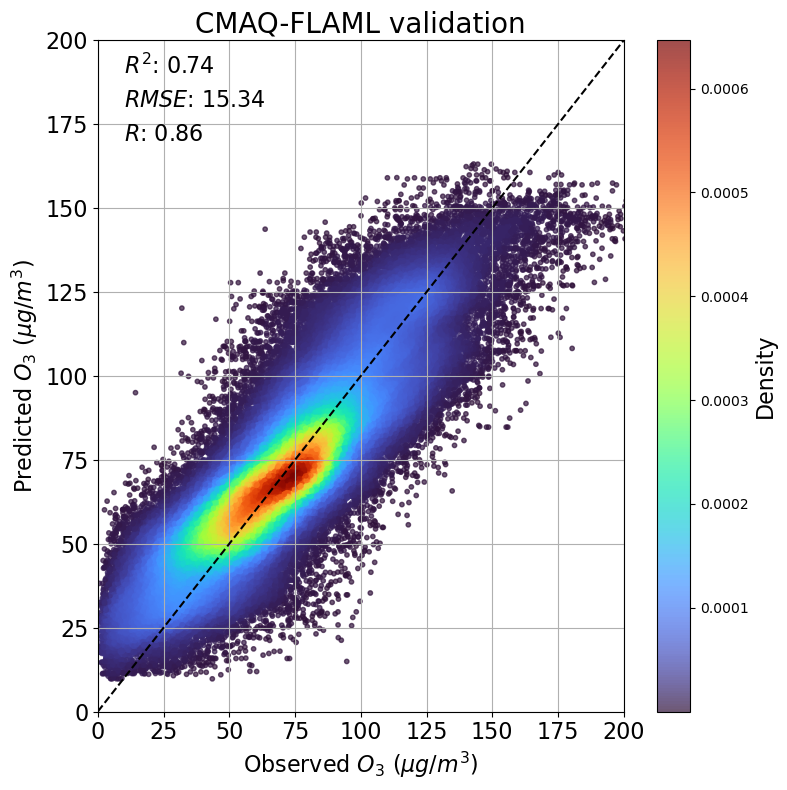

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

a = df_results['obs_8_max']
b = df_results['prediction_1']
xy = np.vstack([a, b])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(8, 8))
scatter_plot=plt.scatter(a, b, c=z, s=10, cmap='turbo', alpha=0.7)
plt.title("CMAQ-FLAML validation", fontsize=20)
plt.plot([0, 200], [0, 200], color="black", linestyle='--')

plt.xlim(0, 200)
plt.ylim(0, 200)

plt.xlabel(r'Observed $O_{3}$ ($\mu g/m^{3}$)', fontsize=16)
plt.ylabel(r'Predicted $O_{3}$ ($\mu g/m^{3}$)', fontsize=16)

plt.text(0.05, 0.95, f"$R^2$: {r2_value_ml:.2f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.9, f"$RMSE$: {rmse_value_ml:.2f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"$R$: {pearson_corr_ml:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

cbar = plt.colorbar(scatter_plot)
cbar.set_label('Density',fontsize=16)

plt.grid()

plt.tight_layout()
plt.show()

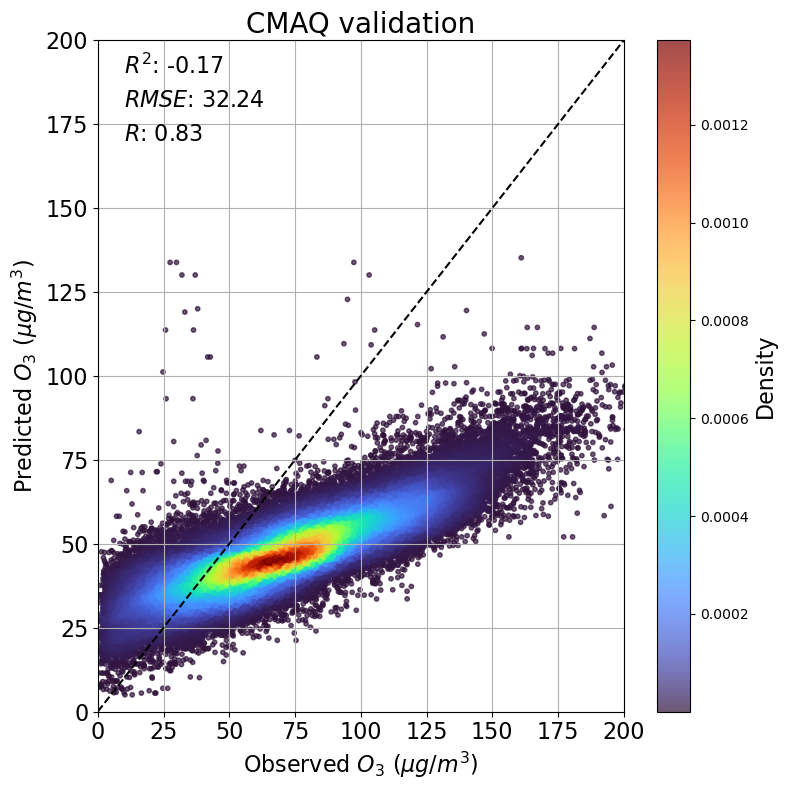

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

a = df_results['obs_8_max']
b = df_results['cmaq_8_max']
xy = np.vstack([a, b])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(8, 8))
scatter_plot=plt.scatter(a, b, c=z, s=10, cmap='turbo', alpha=0.7)
plt.title("CMAQ validation", fontsize=20)
plt.plot([0, 200], [0, 200], color="black", linestyle='--')

plt.xlim(0, 200)
plt.ylim(0, 200)

plt.xlabel(r'Observed $O_{3}$ ($\mu g/m^{3}$)', fontsize=16)
plt.ylabel(r'Predicted $O_{3}$ ($\mu g/m^{3}$)', fontsize=16)

plt.text(0.05, 0.95, f"$R^2$: {r2_value_cmaq:.2f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.9, f"$RMSE$: {rmse_value_cmaq:.2f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"$R$: {pearson_corr_cmaq:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

cbar = plt.colorbar(scatter_plot)
cbar.set_label('Density',fontsize=16)


#sns.despine()
plt.grid()

plt.tight_layout()
plt.show()

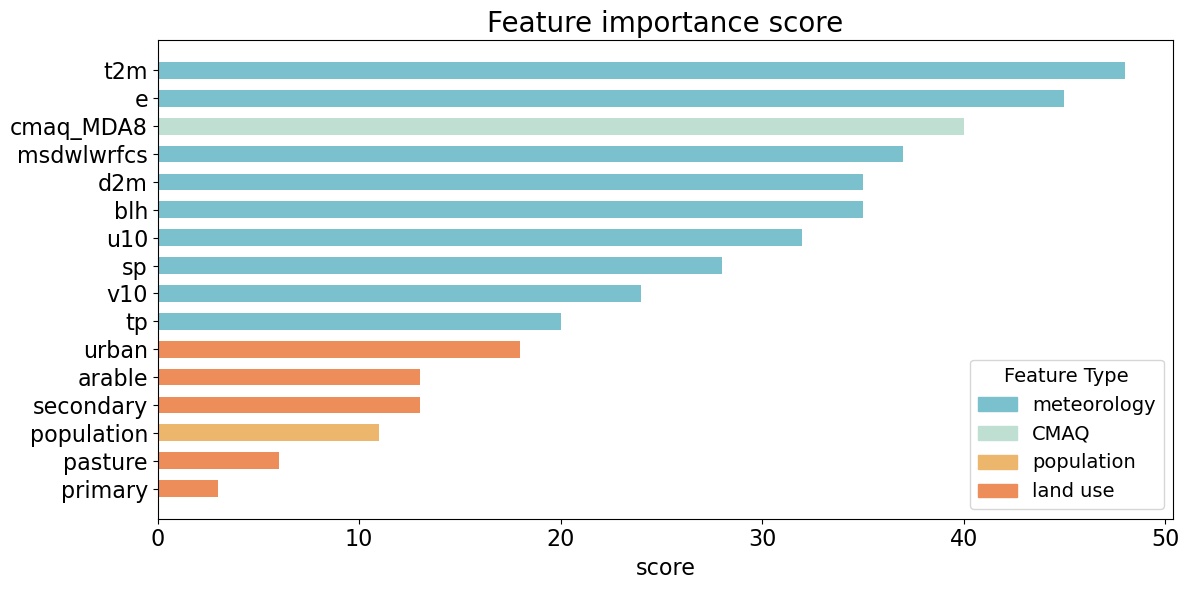

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FormatStrFormatter

data = {
    'Feature': ['t2m', 'e', 'cmaq_MDA8', 'msdwlwrfcs', 'blh', 'u10', 'sp', 
                'd2m', 'v10', 'tp', 'urban', 'secondary', 'arable', 
                'population', 'pasture', 'primary'],
    'score': [48, 45, 40, 37, 35, 32, 28, 35, 24, 20, 18, 13, 13, 11, 6, 3],
    'type': [
        'meteorology', 'meteorology', 'CMAQ', 'meteorology', 
        'meteorology', 'meteorology', 'meteorology',   
        'meteorology', 'meteorology', 'meteorology',
        'land use', 'land use', 'land use',            
        'population', 'land use', 'land use'           
    ]
}

df = pd.DataFrame(data)
df = df.sort_values(by='score', ascending=True)

color_map = {
    'meteorology': '#7bc0cd',    
    'CMAQ': '#bfdfd2',           
    'population': '#ecb66c',     
    'land use': '#ed8d5a'        
}
df['color'] = df['type'].map(color_map)


fig, ax = plt.subplots(figsize=(12, 6))  


y_pos = np.arange(len(df['Feature']))  
ax.barh(y_pos, df['score'], color=df['color'], height=0.6)


ax.set_yticks(y_pos)
ax.set_yticklabels(df['Feature'], fontsize=16)  
ax.set_xlabel('score', fontsize=16)             
ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))  
ax.tick_params(axis='x', labelsize=16)
ax.set_title('Feature importance score', fontsize=20)  

handles = [plt.Rectangle((0,0),1,1, color=color_map[t]) for t in color_map]
ax.legend(handles, color_map.keys(), title='Feature Type',
          loc='lower right',  
          bbox_to_anchor=(1, 0), 
          fontsize=14,
          title_fontsize=14
         )

plt.tight_layout()

plt.show()

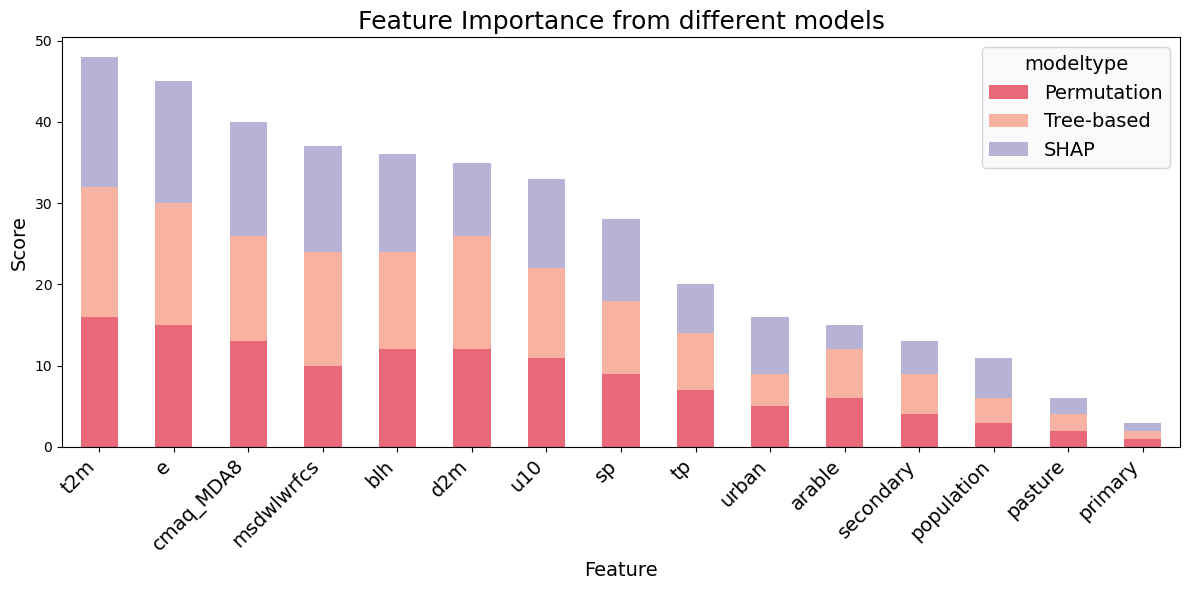

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Feature': ['t2m', 'e', 'msdwlwrfcs', 'cmaq_MDA8', 'd2m', 'blh', 'u10', 'sp', 'tp', 'urban', 'secondary', 'arable', 'population', 'pasture', 'primary'],
    'Permutation': [16, 15, 10, 13, 12, 12, 11, 9, 7, 5, 4, 6, 3, 2, 1],
    'Tree-based': [16, 15, 14, 13, 14, 12, 11, 9, 7, 4, 5, 6, 3, 2, 1],
    'SHAP': [16, 15, 13, 14, 9, 12, 11, 10, 6, 7, 4, 3, 5, 2, 1]
}
df = pd.DataFrame(data)

df['TOTAL']=df['Permutation']+df['SHAP']+df['Tree-based']

df_sorted = df.sort_values(by='TOTAL', ascending=False).set_index('Feature')

plt.figure(figsize=(12, 6))
colors = ['#e9687a', '#f8b2a2', '#b6b3d6']
df_sorted[['Permutation', 'Tree-based', 'SHAP']].plot(
    kind='bar', 
    stacked=True, 
    color=colors, 
    ax=plt.gca()
)

ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.yaxis.set_ticks_position('left')

plt.title('Feature Importance from different models', fontsize=18)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Feature', fontsize=14)  
plt.xticks(rotation=45, ha='right', fontsize=14)  

plt.legend(
    loc='upper right', 
    fontsize=14, 
    title='modeltype',  
    title_fontsize=14,
    facecolor='#f8f9fa'
)
plt.tight_layout()


plt.show()